# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The E-commerce Marketing % Sales Dataset](https://www.kaggle.com/datasets/amineipad/e-commerce-marketing-and-sales-revenue-prediction?select=train.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/amineipad/e-commerce-marketing-and-sales-revenue-prediction/train.csv
/kaggle/input/datasets/amineipad/e-commerce-marketing-and-sales-revenue-prediction/test.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('train.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## last Five row

In [4]:
df.tail()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
17995,17996,2010-10-21 10:49:00,north,Affiliate,Storage,Premium,3.30,0.55,0.2052,1115.0,41984,0.0016,8.02,-0.366025,14.0,2944.95,204.504503
17996,17997,2010-06-16 13:52:00,North,Search,Storage,Premium,5.90,2.95,0.1902,3.0,87,0.0291,5.06,-1.000000,30.0,16828.52,47.295829
17997,17998,2010-09-28 10:24:00,North,Email,General,Premium,NaN,3.75,0.0767,174.0,2605,0.0165,0.74,-1.000000,7.0,NaN,90.457462
17998,17999,2010-10-03 11:53:00,North,Affiliate,Storage,Premium,3.75,3.75,0.0770,227.0,8761,0.0345,4.62,-0.366025,7.0,2243.36,75.691468
17999,18000,2010-12-14 10:46:00,North,Email,Storage,Premium,7.90,3.95,0.1947,536.0,8817,0.0124,4.84,1.000000,90.0,356.59,103.573562


## Shape of our dataset

In [5]:
df.shape

(18000, 17)

## List out all columns

In [6]:
df.columns

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'sales_revenue'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

id                           int64
date                        object
region                      object
channel                     object
product_category            object
customer_segment            object
ad_spend                   float64
price                      float64
discount_rate              float64
market_reach               float64
impressions                  int64
click_through_rate         float64
competition_index          float64
seasonality_index          float64
campaign_duration_days     float64
customer_lifetime_value    float64
sales_revenue              float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

## Check Null Value

In [9]:
df.isnull().sum()

id                            0
date                          0
region                        0
channel                       0
product_category              0
customer_segment              0
ad_spend                    658
price                         0
discount_rate               755
market_reach                686
impressions                   0
click_through_rate          713
competition_index           707
seasonality_index             0
campaign_duration_days     1513
customer_lifetime_value     743
sales_revenue                 0
dtype: int64

## Fill missing values

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

id                         0
date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
dtype: int64


## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,9000.500000,42.895739,5.648265,0.228952,319.396556,7257.423889,0.056600,3.998741,-0.014902,34.929667,9964.835959,137.204937
std,5196.296758,186.754718,22.456661,0.146869,240.351686,7600.666112,0.048536,1.955596,0.919343,25.963015,34880.733586,54.961808
min,1.000000,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000
25%,4500.750000,4.950000,1.250000,0.113200,142.000000,2503.750000,0.021300,2.500000,-1.000000,14.000000,606.397500,100.088209
50%,9000.500000,11.900000,1.950000,0.204000,269.000000,5106.500000,0.043500,3.870000,0.366025,28.000000,1781.440000,129.113361
75%,13500.250000,19.500000,3.750000,0.318900,428.000000,9566.250000,0.077700,5.350000,1.000000,60.000000,5215.275000,164.688454
max,18000.000000,4254.500000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

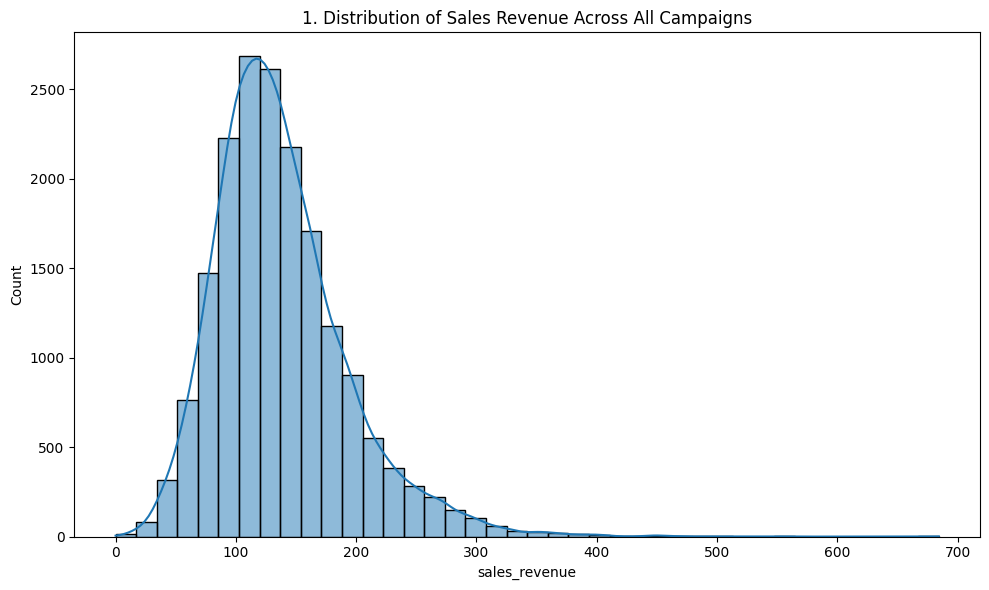

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sales_revenue'], kde=True, bins=40)
plt.title(f'{plot_no}. Distribution of Sales Revenue Across All Campaigns')
show_fig()
plot_no += 1

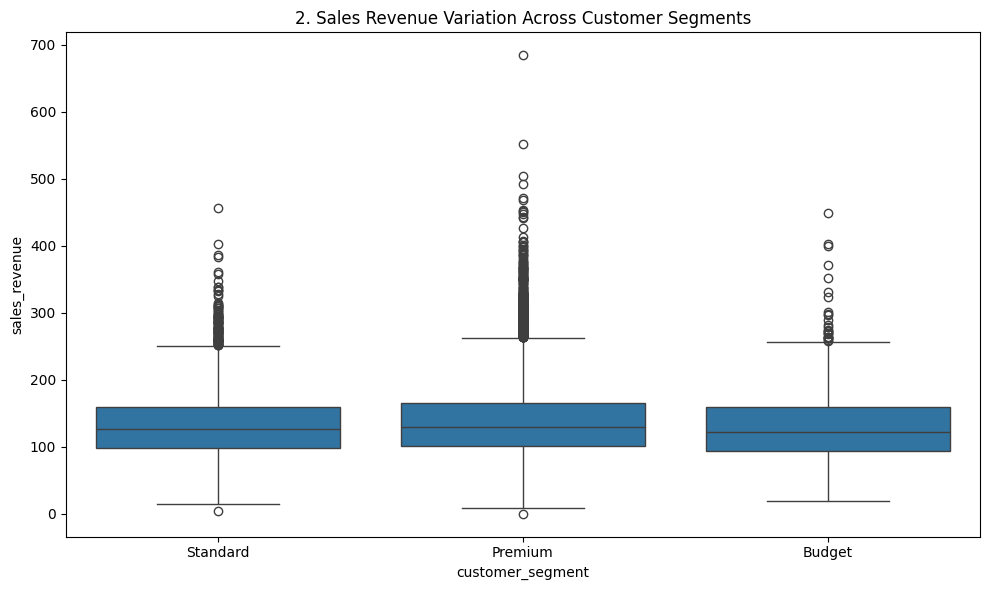

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='customer_segment', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Sales Revenue Variation Across Customer Segments')
show_fig()
plot_no += 1

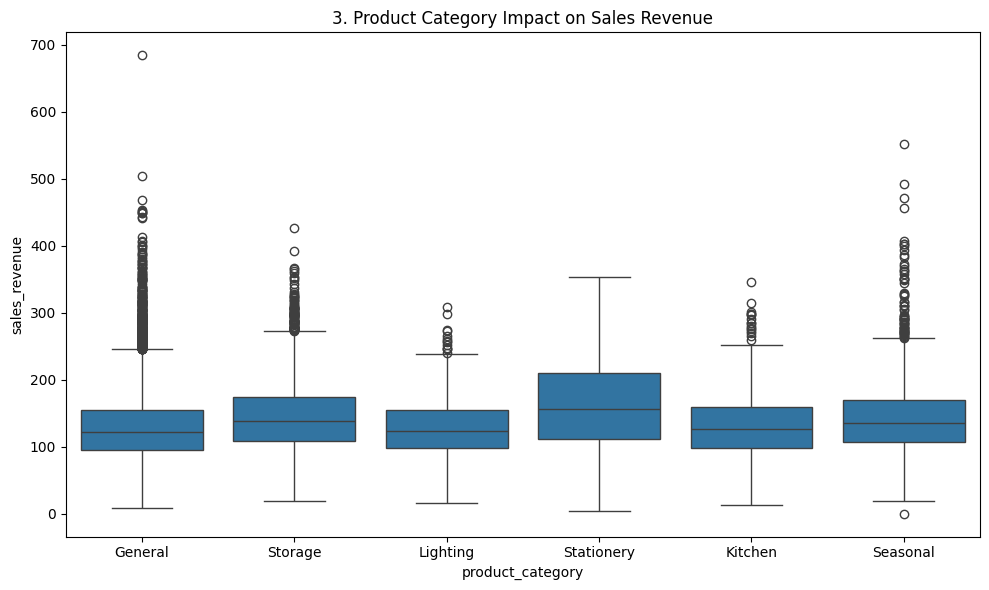

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='product_category', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Product Category Impact on Sales Revenue')
show_fig()
plot_no += 1

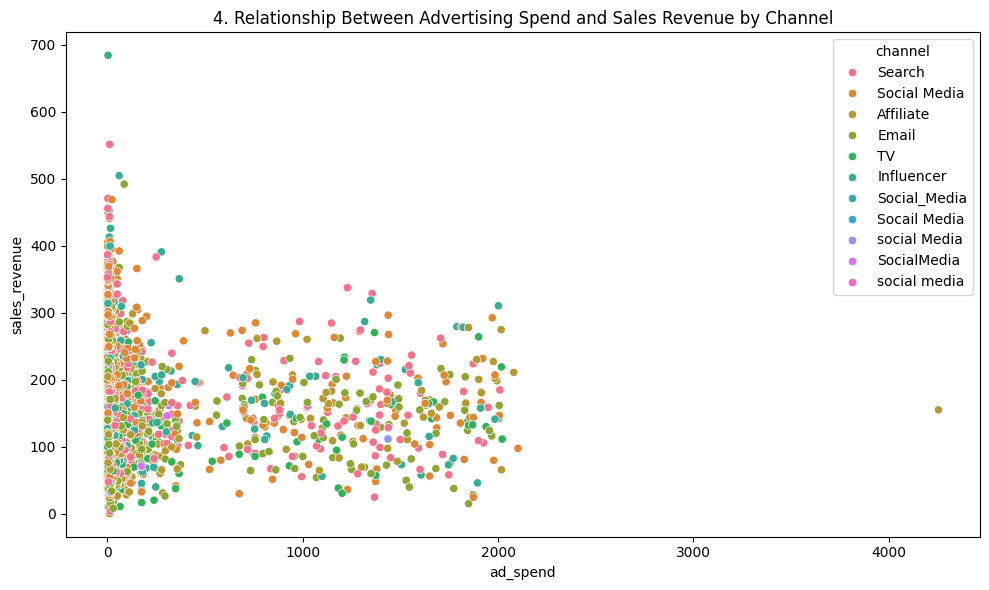

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='ad_spend', y='sales_revenue', hue='channel', data=df)
plt.title(f'{plot_no}. Relationship Between Advertising Spend and Sales Revenue by Channel')
show_fig()
plot_no += 1

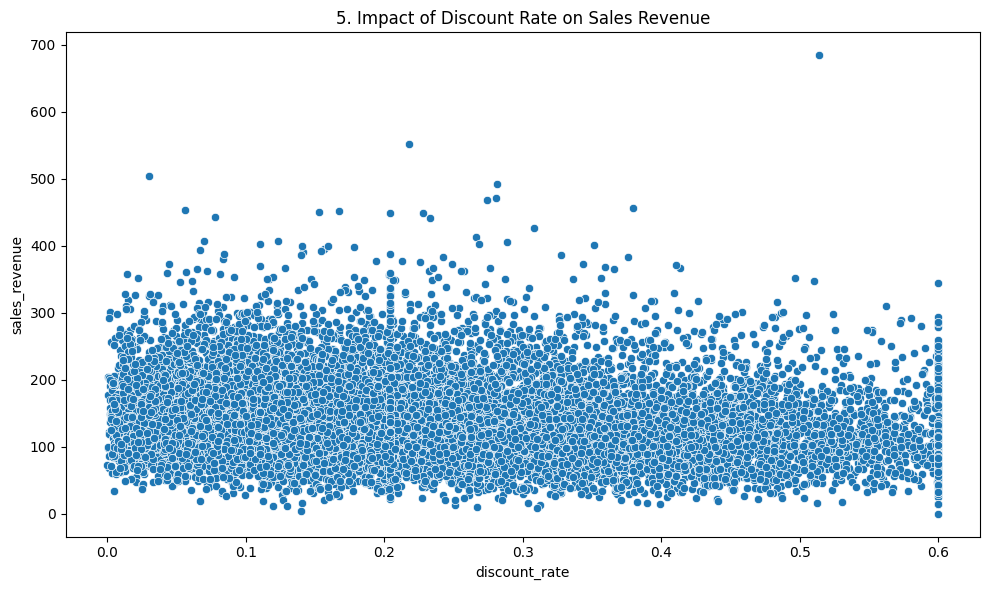

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='discount_rate', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Impact of Discount Rate on Sales Revenue')
show_fig()
plot_no += 1

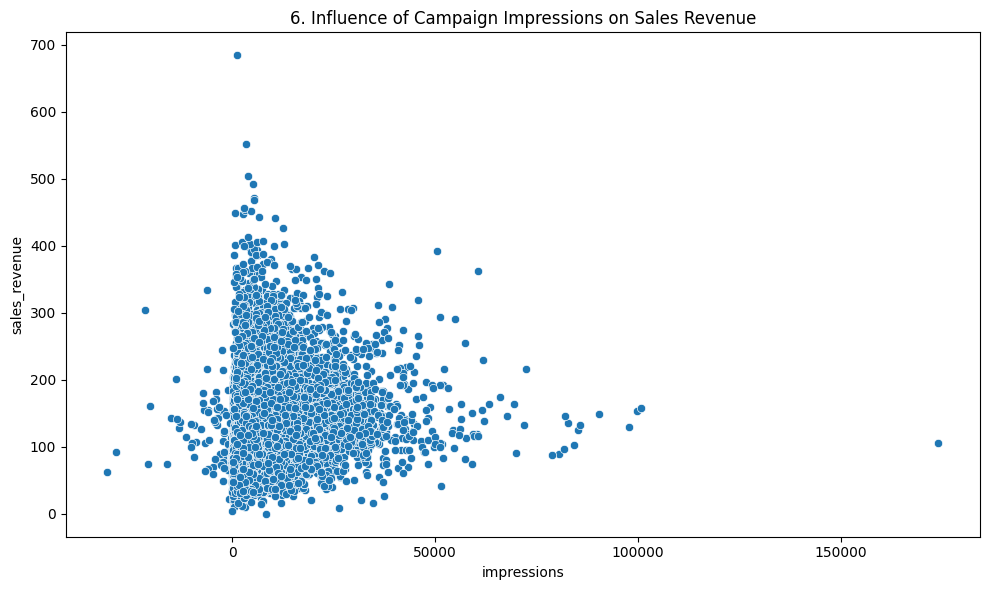

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='impressions', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Influence of Campaign Impressions on Sales Revenue')
show_fig()
plot_no += 1

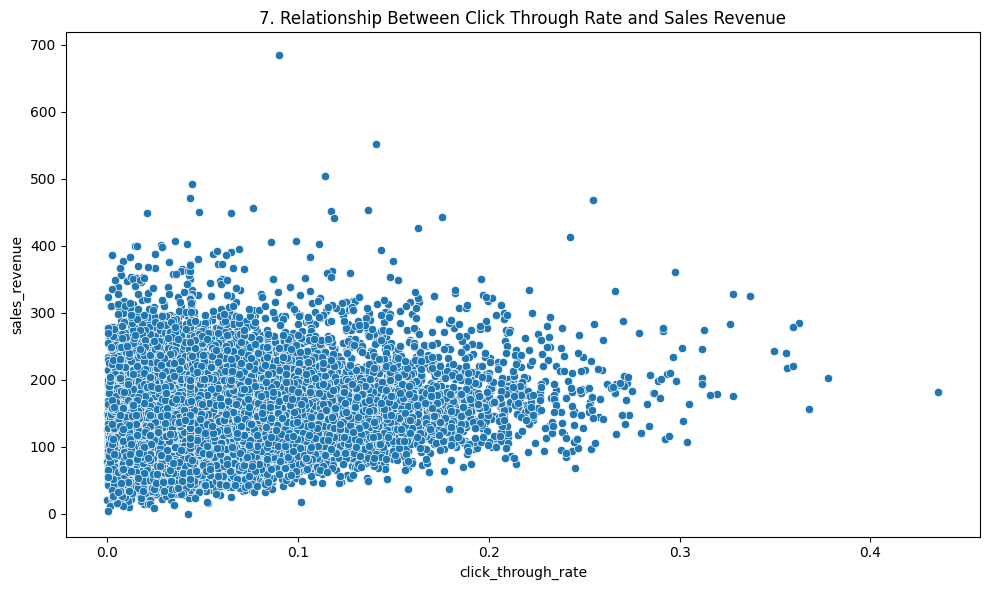

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='click_through_rate', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Relationship Between Click Through Rate and Sales Revenue')
show_fig()
plot_no += 1

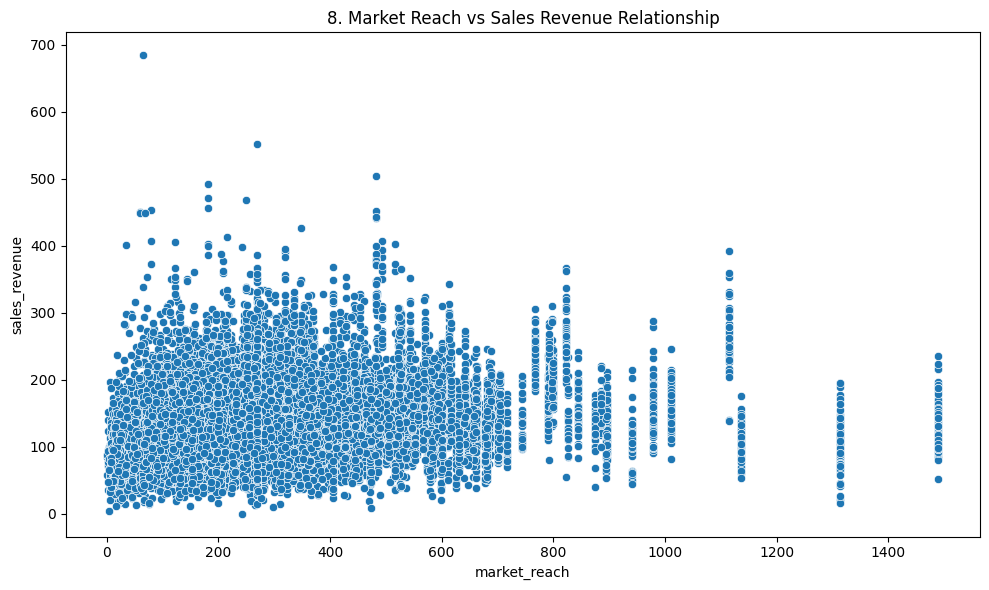

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='market_reach', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Market Reach vs Sales Revenue Relationship')
show_fig()
plot_no += 1

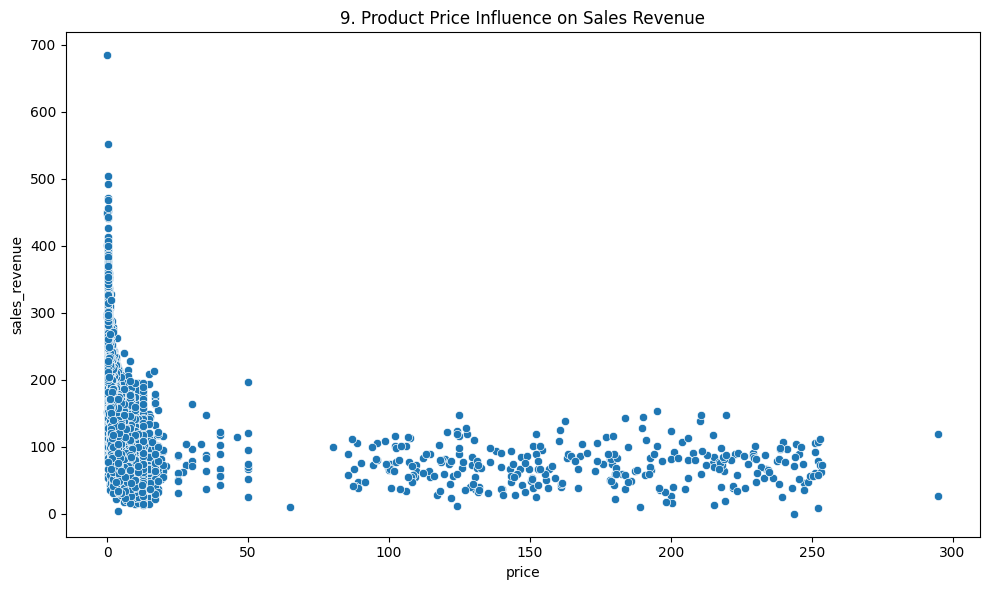

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='price', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Product Price Influence on Sales Revenue')
show_fig()
plot_no += 1

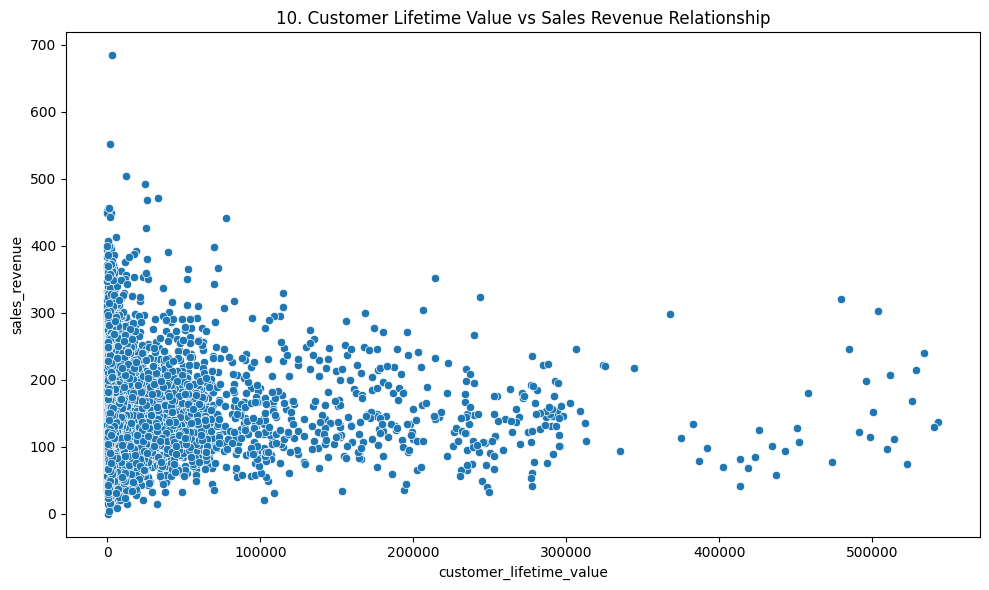

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='customer_lifetime_value', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Customer Lifetime Value vs Sales Revenue Relationship')
show_fig()
plot_no += 1

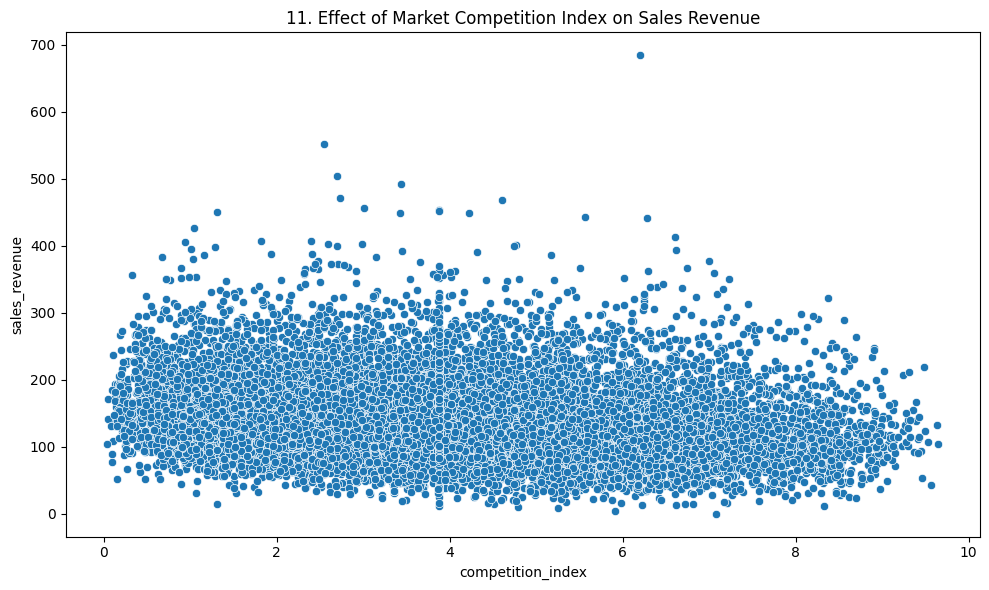

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='competition_index', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Effect of Market Competition Index on Sales Revenue')
show_fig()
plot_no += 1

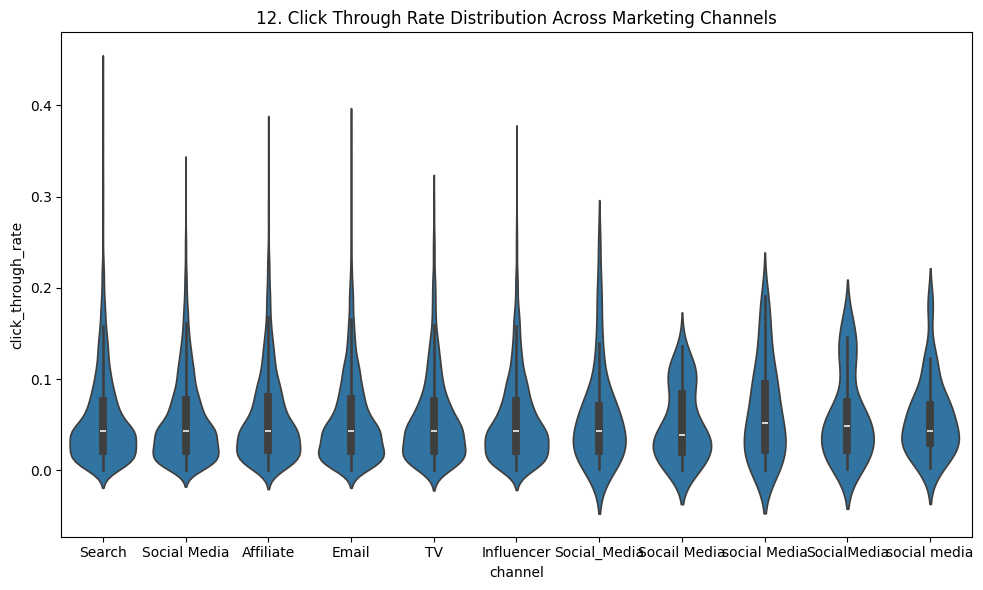

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='channel', y='click_through_rate', data=df)
plt.title(f'{plot_no}. Click Through Rate Distribution Across Marketing Channels')
show_fig()
plot_no += 1

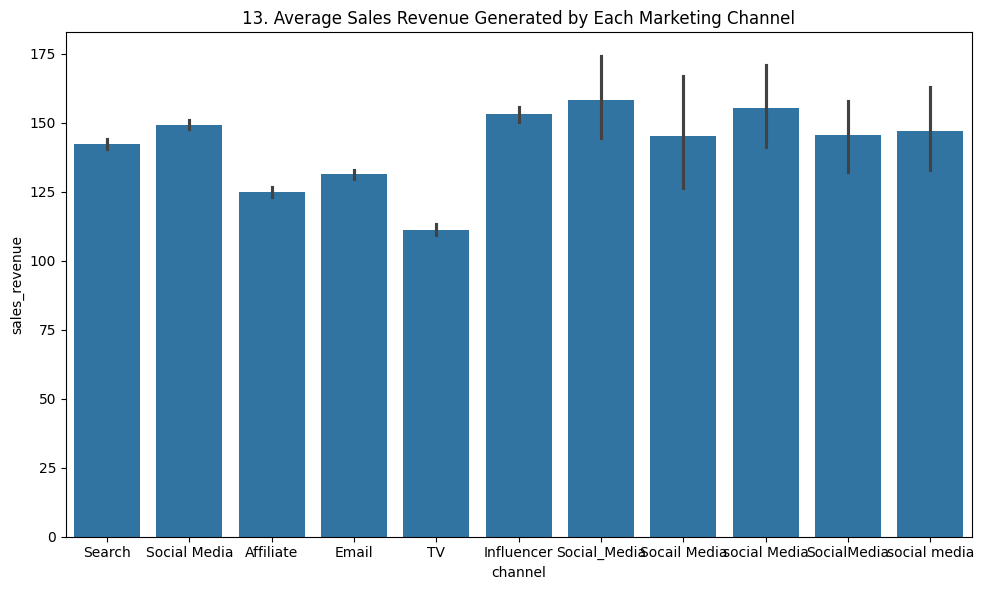

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='channel', y='sales_revenue', data=df)
plt.title(f'{plot_no}. Average Sales Revenue Generated by Each Marketing Channel')
show_fig()
plot_no += 1

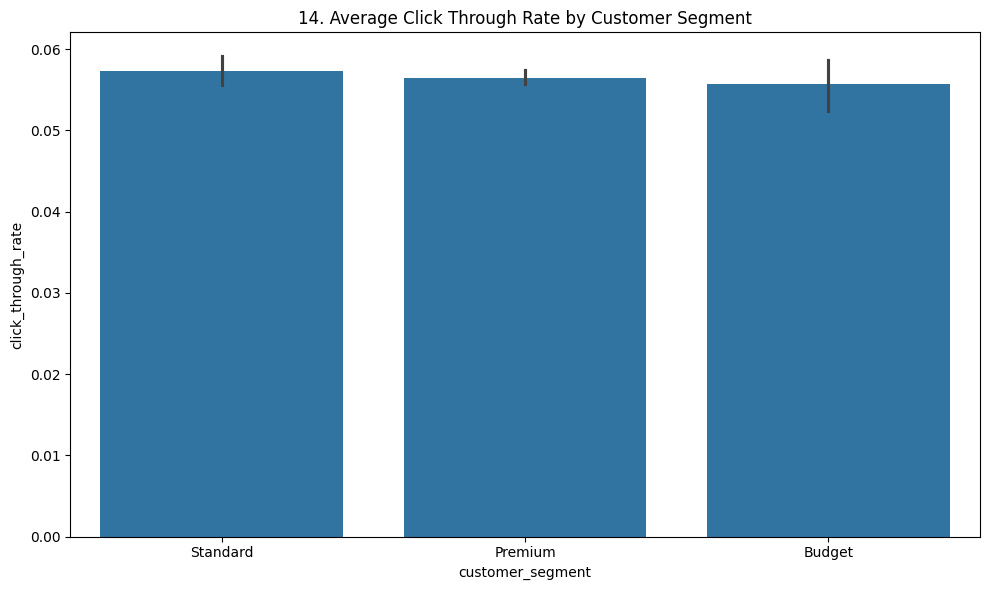

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='customer_segment', y='click_through_rate', data=df)
plt.title(f'{plot_no}. Average Click Through Rate by Customer Segment')
show_fig()
plot_no += 1

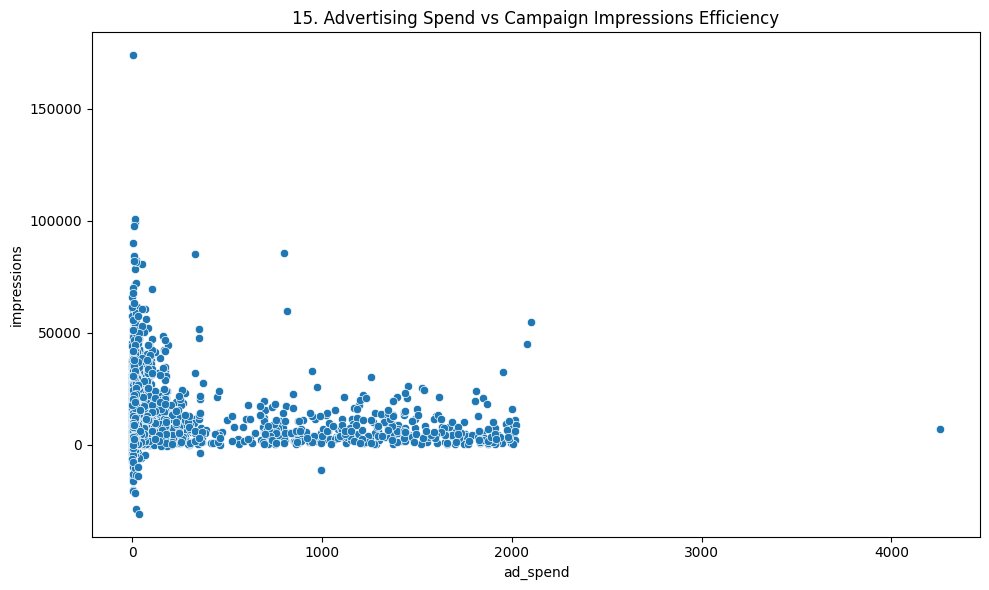

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='ad_spend', y='impressions', data=df)
plt.title(f'{plot_no}. Advertising Spend vs Campaign Impressions Efficiency')
show_fig()
plot_no += 1

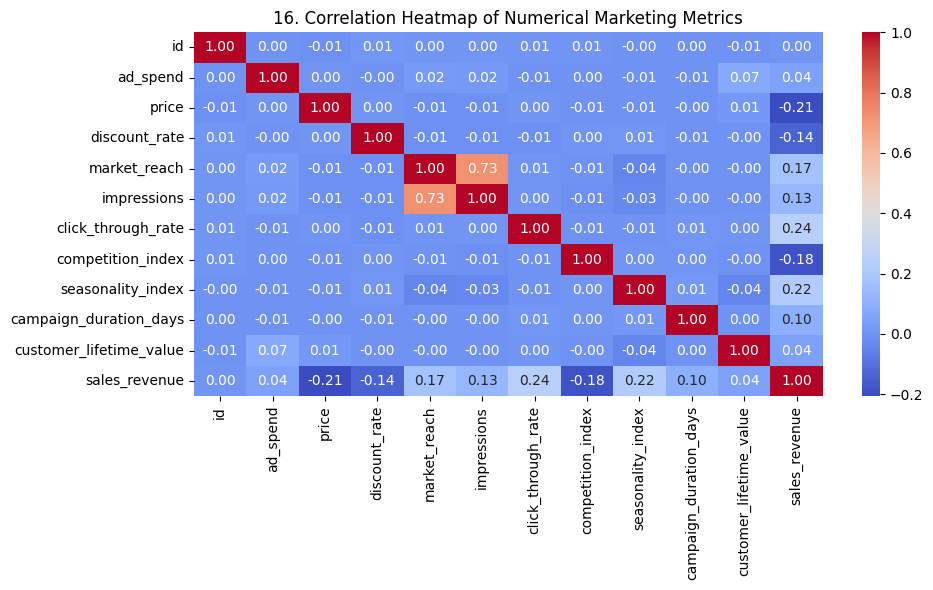

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Marketing Metrics')
show_fig()
plot_no += 1

# Model Training

## convert sales_revenue into binary target for classification

In [30]:
df['target'] = (df['sales_revenue'] > df['sales_revenue'].median()).astype(int)

## select numerical features

In [31]:
features = ['ad_spend','price','discount_rate','market_reach','impressions',
            'click_through_rate','competition_index','seasonality_index',
            'campaign_duration_days','customer_lifetime_value']

X = df[features]
y = df['target']

## split dataset into train and test sets

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train Logistic Regression model

In [34]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## make predictions

In [35]:
y_pred = model.predict(X_test)

## calculate accuracy

In [36]:
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.7944444444444444


## compute confusion matrix

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1395  357]
 [ 383 1465]]


## plot confusion matrix

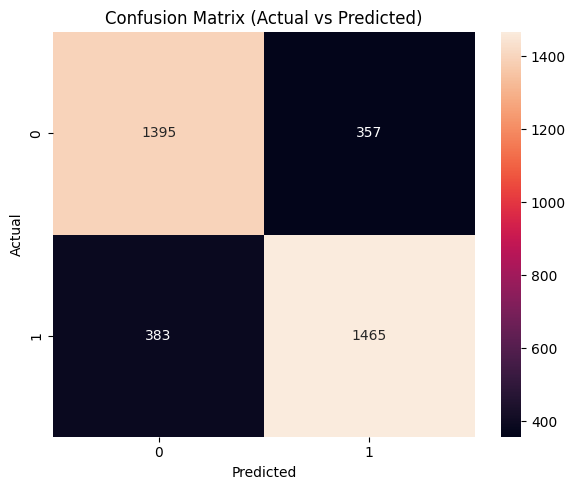

In [38]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Actual vs Predicted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()